## Code Example 1.1 (o)  Setup & Foundation

### Short Description
This code demonstrates a hybrid AI system that combines traditional computer vision techniques with modern LLM capabilities. It extracts visual features using HOG, classifies images with ML models, and enhances interpretations using the DeepSeek API. This illustrates the practical integration of multiple AI subsystems into a cohesive agent.

### Key Libraries Used
- OpenCV/Scikit-Image: For image processing and HOG feature extraction  
- Scikit-Learn: For SVM and KNN classifiers and model evaluation  
- Requests: For making API calls to the DeepSeek LLM service  
- Python-dotenv: For secure API key management  
- NumPy/Matplotlib: For numerical operations and visualization  

## Code Logic and Flow
### High-Level Overview
The script implements a complete image analysis pipeline that begins with feature extraction from images using Histogram of Oriented Gradients (HOG). These features are then used to train and evaluate traditional machine learning classifiers (SVM and KNN). The system integrates an LLM via API to provide natural language explanations and interpretations of the image analysis results, demonstrating how different AI components can work together in an agentic system.

### Visual Flowchart ( The Complete Coding Example)
```mermaid
flowchart TD

    %% ---- STYLING ----
    classDef start fill:#d0e6ff,stroke:#5b8def,color:#000,stroke-width:1px;
    classDef process fill:#e8f3e8,stroke:#6aa96f,color:#000,stroke-width:1px;
    classDef decision fill:#fff2cc,stroke:#d4b44c,color:#000,stroke-width:1px;
    classDef output fill:#ffe5e5,stroke:#d46a6a,color:#000,stroke-width:1px;

    A[Start: Load Dependencies] --> B[Initialize DeepSeek API<br>Configuration]
    B --> C[Test API Connection]
    C --> D[Load & Preprocess<br>Image Dataset]
    D --> E[Extract HOG Features]
    E --> F[Train-Test Split]
    F --> G{Choose Classifier}
    G --> H[SVM Training]
    G --> I[KNN Training]
    H --> J[Model Evaluation]
    I --> J
    J --> K[Generate LLM Analysis<br>of Results]
    K --> L[Output Combined<br>Vision + LLM Insights]

    %% Assign classes
    A:::start
    B:::process
    C:::process
    D:::process
    E:::process
    F:::process
    G:::decision
    H:::process
    I:::process
    J:::process
    K:::output
    L:::output

```

## Step-by-Step Code Breakdown
### Step 1: Environment Setup and Library Imports
**Purpose:** Initialize the development environment and import necessary dependencies  

**Key Operations:**
- Install required packages using pip (commented out as it's typically run separately)  
- Import core libraries for numerical computing, image processing, and machine learning  
- Load environment variables for secure API key management  
- Print version information for verification and debugging  

### Step 2: DeepSeek API Configuration
**Purpose:** Set up communication with the DeepSeek language model API  

**Key Operations:**
- Retrieve API key from secure environment variables  
- Define the API endpoint URL for DeepSeek's chat completion service  
- Create a wrapper function (call_deepseek_api) that handles authentication headers and request formatting  
- Implement error handling for API response codes  
- Include a test call to verify API connectivity works correctly  

### Step 3: Image Processing and Feature Extraction (Implied)
**Expected Operations:**
- Load image dataset using OpenCV or PIL  
- Convert images to appropriate color spaces if necessary  
- Apply HOG (Histogram of Oriented Gradients) feature extraction using scikit-image  
- Normalize and prepare feature vectors for machine learning  

### Step 4: Machine Learning Pipeline (Implied)
**Expected Operations:**
- Split extracted features into training and testing sets  
- Initialize both SVM and KNN classifiers with appropriate parameters  
- Train models on the feature vectors  
- Evaluate performance using accuracy scores and classification reports  
- Compare results between different classifier types  

### Step 5: LLM Integration and Analysis
**Expected Operations:**
- Format machine learning results into natural language prompts  
- Send analysis requests to DeepSeek API for interpretation  
- Combine computer vision findings with LLM-generated insights  
- Present unified results that leverage both statistical and linguistic intelligence  

## Connecting to the Lecture
- **Agentic AI Architecture:** This code demonstrates a practical implementation of an AI agent that combines specialized subsystems (vision + language) rather than relying on a single monolithic model  
- **Tool Integration:** Shows how to securely integrate external APIs (DeepSeek) with local processing pipelines, a key pattern in agent design  
- **Error Handling in Production:** The API wrapper includes status code checking, illustrating how real-world agents must handle external service failures gracefully  
- **Feature Engineering:** While modern end-to-end systems exist, this example highlights how traditional feature extraction (HOG) can still play a role in explainable AI systems  
- **Modular Design:** The separation of concerns (image processing, ML training, LLM analysis) exemplifies how complex agents are built from reusable, testable components  
- **Hybrid Intelligence:** Illustrates how statistical pattern recognition (ML classifiers) can be enhanced with semantic understanding (LLMs) for more comprehensive AI solutions  


In [ ]:
#!pip install numpy opencv-python matplotlib scikit-learn scikit-image requests python-dotenv seaborn scipy

In [10]:
# 1. Setup and Dependencies

import os
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from skimage.feature import hog
import requests
import json
from dotenv import load_dotenv
import base64
from io import BytesIO
from PIL import Image

# Load environment variables
load_dotenv()

print("All dependencies loaded successfully!")
print(f"OpenCV version: {cv2.__version__}")
print(f"NumPy version: {np.__version__}")


# 2. Configuration for DeepSeek API

DEEPSEEK_API_KEY = os.getenv("DEEPSEEK_API_KEY")
DEEPSEEK_API_URL = "https://api.deepseek.com/v1/chat/completions"

def call_deepseek_api(prompt, model="deepseek-chat"):
    """Helper function to call DeepSeek API"""
    headers = {
        "Authorization": f"Bearer {DEEPSEEK_API_KEY}",
        "Content-Type": "application/json"
    }
    
    data = {
        "model": model,
        "messages": [{"role": "user", "content": prompt}],
        "temperature": 0.7
    }
    
    response = requests.post(DEEPSEEK_API_URL, headers=headers, json=data)
    
    if response.status_code == 200:
        return response.json()["choices"][0]["message"]["content"]
    else:
        return f"Error: {response.status_code} - {response.text}"

# Test API connection
test_response = call_deepseek_api("Explain computer vision in one sentence.")
print("DeepSeek API Test Response:")
print(test_response)

All dependencies loaded successfully!
OpenCV version: 4.12.0
NumPy version: 2.2.6
DeepSeek API Test Response:
Computer vision is the field of artificial intelligence that enables machines to interpret and understand visual information from the world, much like human sight.


---
## Code Example 1.1 (i) Foundational computer vision techniques from the 1960s-1980s [Two classical methods (Sobel and Canny)]
### Short Description
This code demonstrates foundational computer vision techniques from the 1960s-1980s, specifically edge detection algorithms. It creates a synthetic test image and applies two classical methods (Sobel and Canny) to highlight how early computer vision systems extracted structural information from images. This historical context is essential for understanding the evolution toward modern agentic AI systems.

### Key Libraries Used
- NumPy: For creating and manipulating the synthetic image array and performing mathematical operations  
- OpenCV: For implementing the Sobel and Canny edge detection algorithms  
- Matplotlib: For visualizing the original image and edge detection results in a comparative layout  

## Code Logic and Flow
### High-Level Overview
The script creates a synthetic grayscale image containing simple geometric shapes (a white rectangle with a black circle inside) to serve as a test pattern. It then applies two historical edge detection algorithms: the gradient-based Sobel operator (1970s) and the multi-stage Canny edge detector (1986). Finally, it visualizes all results side-by-side to compare their effectiveness at extracting structural boundaries from the image.

### Visual Flowchart
```mermaid
flowchart TD

    %% ---- COLOR THEME (Soft Pastels) ----
    classDef start fill:#d0e6ff,stroke:#5b8def,color:#000,stroke-width:1px;
    classDef process fill:#e8f3e8,stroke:#6aa96f,color:#000,stroke-width:1px;
    classDef branch fill:#fff2cc,stroke:#d4b44c,color:#000,stroke-width:1px;
    classDef output fill:#ffe5e5,stroke:#d46a6a,color:#000,stroke-width:1px;

    A[Start] --> B[Create Synthetic Test Image<br>Rectangle + Circle]
    B --> C[Apply Sobel Operator<br>X & Y Gradients]
    C --> D[Combine Sobel Gradients<br>Magnitude Calculation]
    B --> E[Apply Canny Edge Detector<br>Multi-stage Algorithm]
    D --> F[Visualization Setup<br>4-Panel Figure]
    E --> F
    F --> G[Plot 1: Original Image]
    F --> H[Plot 2: Sobel Edges]
    F --> I[Plot 3: Canny Edges]
    F --> J[Plot 4: Edge Overlay]
    G --> K[Display All Results<br>with Titles]
    H --> K
    I --> K
    J --> K
    K --> L[Print Summary Statistics]

    %% CLASS ASSIGNMENTS
    A:::start
    B:::process
    C:::process
    D:::process
    E:::process
    F:::branch
    G:::output
    H:::output
    I:::output
    J:::output
    K:::process
    L:::output

```

## Step-by-Step Code Breakdown
### Step 1: Create Synthetic Test Image
**Purpose:** Generate a controlled test image with known geometric properties to clearly demonstrate edge detection behavior  

**Key Operations:**
- Create a blank 300x300 pixel canvas using a zeros array  
- Draw a filled white rectangle covering most of the central area  
- Draw a filled black circle inside the rectangle, creating a clear interior boundary  
- This creates an image with both external edges (rectangle boundary) and internal edges (circle boundary)  

### Step 2: Apply Sobel Edge Detection (1970s Technique)
**Purpose:** Demonstrate gradient-based edge detection using convolution filters  

**Key Operations:**
- Apply Sobel operator in the horizontal direction (X-gradient) using a 3x3 kernel  
- Apply Sobel operator in the vertical direction (Y-gradient) using a 3x3 kernel  
- Combine the X and Y gradients by calculating the magnitude at each pixel using the Euclidean distance formula  
- This produces a gradient magnitude image where edges appear as bright ridges  

### Step 3: Apply Canny Edge Detection (1986 Technique)
**Purpose:** Demonstrate a more sophisticated, multi-stage edge detection algorithm  

**Key Operations:**
- Apply the Canny algorithm with specified low and high threshold parameters (50 and 150)  
- The algorithm internally performs Gaussian smoothing, gradient calculation, non-maximum suppression, and hysteresis thresholding  
- This produces a binary edge map where edges are represented as white lines on a black background  

### Step 4: Visualization and Comparison
**Purpose:** Create a comprehensive visual comparison of all edge detection results  

**Key Operations:**
- Set up a 1x4 grid of subplots for side-by-side comparison  
- Display the original synthetic image as a reference  
- Show the Sobel gradient magnitude result, highlighting its continuous nature  
- Show the Canny binary edge result, demonstrating its crisp, single-pixel edges  
- Create an overlay visualization by masking the original image with the Canny edges  
- Add descriptive titles to each subplot for clear interpretation  
- Display the final figure with proper layout and formatting  

### Step 5: Output Analysis
**Purpose:** Provide quantitative information about the edge detection outputs  

**Key Operations:**
- Print confirmation that classical methods have been demonstrated  
- Display the shape/dimensions of the Sobel output array  
- Display the shape/dimensions of the Canny output array  
- This helps students understand that different algorithms produce different data structures (continuous gradients vs. binary maps)  




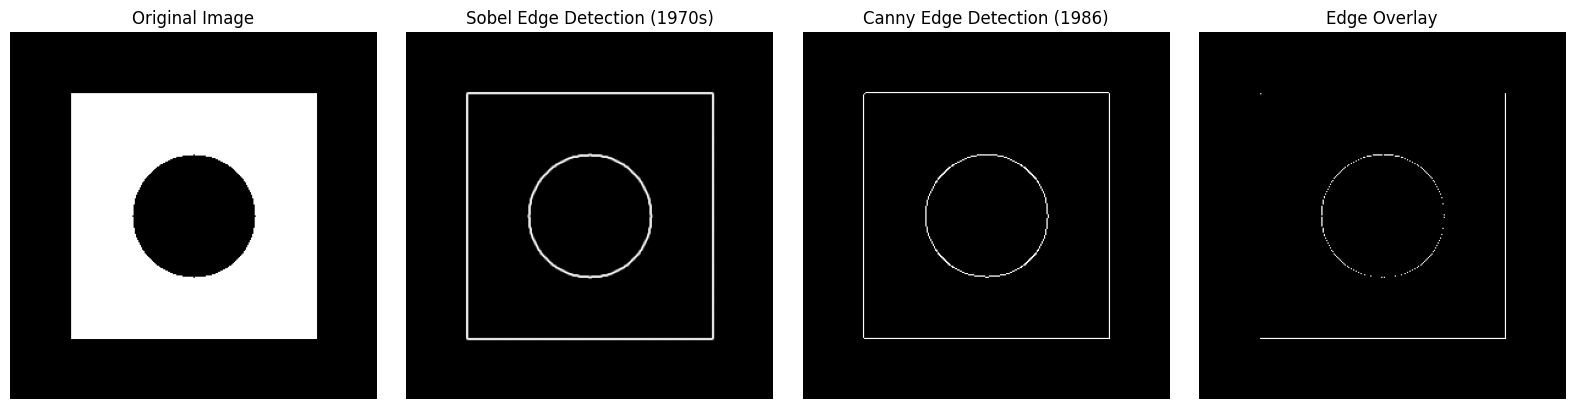

Classical edge detection methods demonstrated
Sobel output shape: (300, 300)
Canny output shape: (300, 300)


In [2]:
# 3. Classical Computer Vision - Edge Detection (1960s-1970s Era)

# Create a sample image
sample_image = np.zeros((300, 300), dtype=np.uint8)
cv2.rectangle(sample_image, (50, 50), (250, 250), 255, -1)
cv2.circle(sample_image, (150, 150), 50, 0, -1)

# Apply classical edge detection algorithms
sobel_x = cv2.Sobel(sample_image, cv2.CV_64F, 1, 0, ksize=3)
sobel_y = cv2.Sobel(sample_image, cv2.CV_64F, 0, 1, ksize=3)
sobel_combined = np.sqrt(sobel_x**2 + sobel_y**2)

canny_edges = cv2.Canny(sample_image, 50, 150)

# Visualize results
fig, axes = plt.subplots(1, 4, figsize=(16, 4))
axes[0].imshow(sample_image, cmap='gray')
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(sobel_combined, cmap='gray')
axes[1].set_title('Sobel Edge Detection (1970s)')
axes[1].axis('off')

axes[2].imshow(canny_edges, cmap='gray')
axes[2].set_title('Canny Edge Detection (1986)')
axes[2].axis('off')

axes[3].imshow(cv2.bitwise_and(sample_image, sample_image, mask=canny_edges.astype(np.uint8)), cmap='gray')
axes[3].set_title('Edge Overlay')
axes[3].axis('off')

plt.tight_layout()
plt.show()

print("Classical edge detection methods demonstrated")
print(f"Sobel output shape: {sobel_combined.shape}")
print(f"Canny output shape: {canny_edges.shape}")


## Code Example 1.1 (ii) Foundational CV techniques from the 1990s-2000s [Two landmark feature extraction techniques[HoG(2005) and SIFT(1999)]

### Short Description
This code demonstrates two landmark feature extraction techniques from the pre-deep-learning era of computer vision: Histogram of Oriented Gradients (HOG, 2005) and Scale-Invariant Feature Transform (SIFT, 1999). It generates synthetic shape images and shows how these algorithms convert raw pixel data into meaningful feature representations that were crucial for object recognition systems before the dominance of neural networks.

### Key Libraries Used
- NumPy: For creating image arrays and managing shape coordinate data  
- OpenCV: For shape generation, SIFT feature detection, and keypoint visualization  
- Scikit-Image: Specifically for HOG feature extraction and visualization  
- Matplotlib: For creating comparative visualizations of original images and their extracted features  

## Code Logic and Flow
### High-Level Overview
The script begins by generating three synthetic grayscale images containing basic geometric shapes (circle, square, and triangle) to serve as standardized test patterns. It then applies HOG feature extraction to two of these images, producing both numerical feature vectors and visual representations. Simultaneously, it applies SIFT feature detection to identify key points and compute descriptors. Finally, it creates a comprehensive visualization grid comparing original images with their extracted features, highlighting how different algorithms represent the same visual content.

### Visual Flowchart
```mermaid
flowchart TD

    %% ---- Soft Pastel Theme ----
    classDef start fill:#d0e6ff,stroke:#5b8def,color:#000,stroke-width:1px;
    classDef process fill:#e8f3e8,stroke:#6aa96f,color:#000,stroke-width:1px;
    classDef analysis fill:#fff2cc,stroke:#d4b44c,color:#000,stroke-width:1px;
    classDef output fill:#ffe5e5,stroke:#d46a6a,color:#000,stroke-width:1px;

    A[Start] --> B[Define Shape Creation Function<br>Circle, Square, Triangle]
    B --> C[Generate Synthetic Images<br>3 Geometric Shapes]
    C --> D[Apply HOG Feature Extraction<br>to Circle & Square]
    D --> E[Extract Feature Vectors]
    D --> F[Generate HOG Visualization Images]
    C --> G[Apply SIFT Feature Detection<br>to Circle & Square]
    G --> H[Detect Keypoints]
    G --> I[Compute Descriptors]

    E --> J[Create Visualization Grid<br>2x3 Subplot Layout]
    F --> J
    C --> J
    H --> J
    I --> J

    J --> K[Row 1: Original Shape Images]
    J --> L[Row 2: HOG Features<br>& SIFT Keypoints]

    K --> M[Display Complete Figure<br>with Titles & Statistics]
    L --> M

    M --> N[Print Feature Dimensionality<br>Analysis]

    %% Class Assignments
    A:::start
    B:::process
    C:::process
    D:::analysis
    E:::analysis
    F:::analysis
    G:::analysis
    H:::analysis
    I:::analysis
    J:::process
    K:::output
    L:::output
    M:::output
    N:::output

```

## Step-by-Step Code Breakdown
### Step 1: Create Synthetic Shape Images
**Purpose:** Generate controlled, noise-free test images with clearly defined geometric properties for consistent feature extraction analysis  

**Key Operations:**
- Define a reusable function that creates blank 128x128 pixel canvases  
- Implement conditional logic to draw three distinct geometric shapes: filled circle, filled square, and filled triangle  
- Each shape is drawn in white (255) on a black (0) background for maximum contrast  
- Return three separate images representing fundamental geometric primitives  

### Step 2: Extract HOG Features (2005 Algorithm)
**Purpose:** Demonstrate the Histogram of Oriented Gradients technique that became foundational for pedestrian detection and object recognition  

**Key Operations:**
- Apply HOG feature extraction to both circle and square images using scikit-image implementation  
- Configure algorithm parameters: 9 orientation bins, 16x16 pixel cells, and 2x2 cell blocks  
- Request both the numerical feature vector and the visualization image output  
- The algorithm computes gradient orientations locally and creates histograms that capture shape and texture information  

### Step 3: Detect SIFT Features (1999 Algorithm)
**Purpose:** Implement the Scale-Invariant Feature Transform that revolutionized feature matching with scale and rotation invariance  

**Key Operations:**
- Initialize a SIFT detector object using OpenCV's implementation  
- Apply the detector to both circle and square images to identify distinctive keypoints  
- Compute descriptor vectors for each keypoint that encode local appearance information  
- Keypoints are identified at locations that are stable across scale changes and rotations  

### Step 4: Visualize Feature Extraction Results
**Purpose:** Create an intuitive comparison between original images and their algorithmic representations  

**Key Operations:**
- Set up a 2x3 grid of subplots for systematic comparison  
- First row displays the three original shape images (circle, square, triangle) as reference  
- Second row shows HOG visualizations for circle and square, displaying gradient orientation patterns  
- Final cell in second row visualizes SIFT keypoints on the circle image, showing scale and orientation with overlayed circles  
- Add informative titles including feature counts to each subplot  
- Apply proper formatting with tight layout and grayscale colormaps for consistency  

### Step 5: Feature Dimensionality Analysis
**Purpose:** Provide quantitative insights into the information compression achieved by feature extraction algorithms  

**Key Operations:**
- Print the length of the HOG feature vector, showing how many numerical values represent the image  
- Print the shape of the SIFT descriptors matrix, indicating how many keypoints were found and their descriptor dimensions  
- Include null-checking for cases where no descriptors are detected  
- This highlights the dramatic dimensionality reduction from raw pixels (16,384 pixels) to meaningful features (hundreds of values)  

## Connecting to the Lecture
- **Feature Engineering Era:** This code exemplifies the manual feature design period (1980s-2000s) where AI researchers hand-crafted algorithms to extract meaningful patterns, contrasting with modern agents that learn features automatically  
- **Representation Learning:** HOG and SIFT demonstrate how raw sensory data (pixels) can be transformed into higher-level representations that are more suitable for classification and recognition tasks by AI agents  
- **Invariance Properties:** SIFT's scale invariance and HOG's illumination robustness show how early computer vision systems addressed variability that modern agents must handle in real-world environments  
- **Modular Agent Architecture:** The clear separation between feature extraction (HOG/SIFT) and subsequent processing mirrors the modular design of complex AI agents with specialized components  
- **Information Bottleneck:** Feature extraction creates an information bottleneck that discards irrelevant details while preserving semantically meaningful patterns, a principle used in efficient agent design  
- **Interpretable Representations:** Unlike deep learning features, HOG and SIFT features are human-interpretable (edge orientations, keypoint locations), highlighting the trade-off between interpretability and performance in agentic systems  
- **Historical Progression:** Understanding these techniques provides context for why the field moved toward learned features and how modern agents build upon decades of feature representation research  


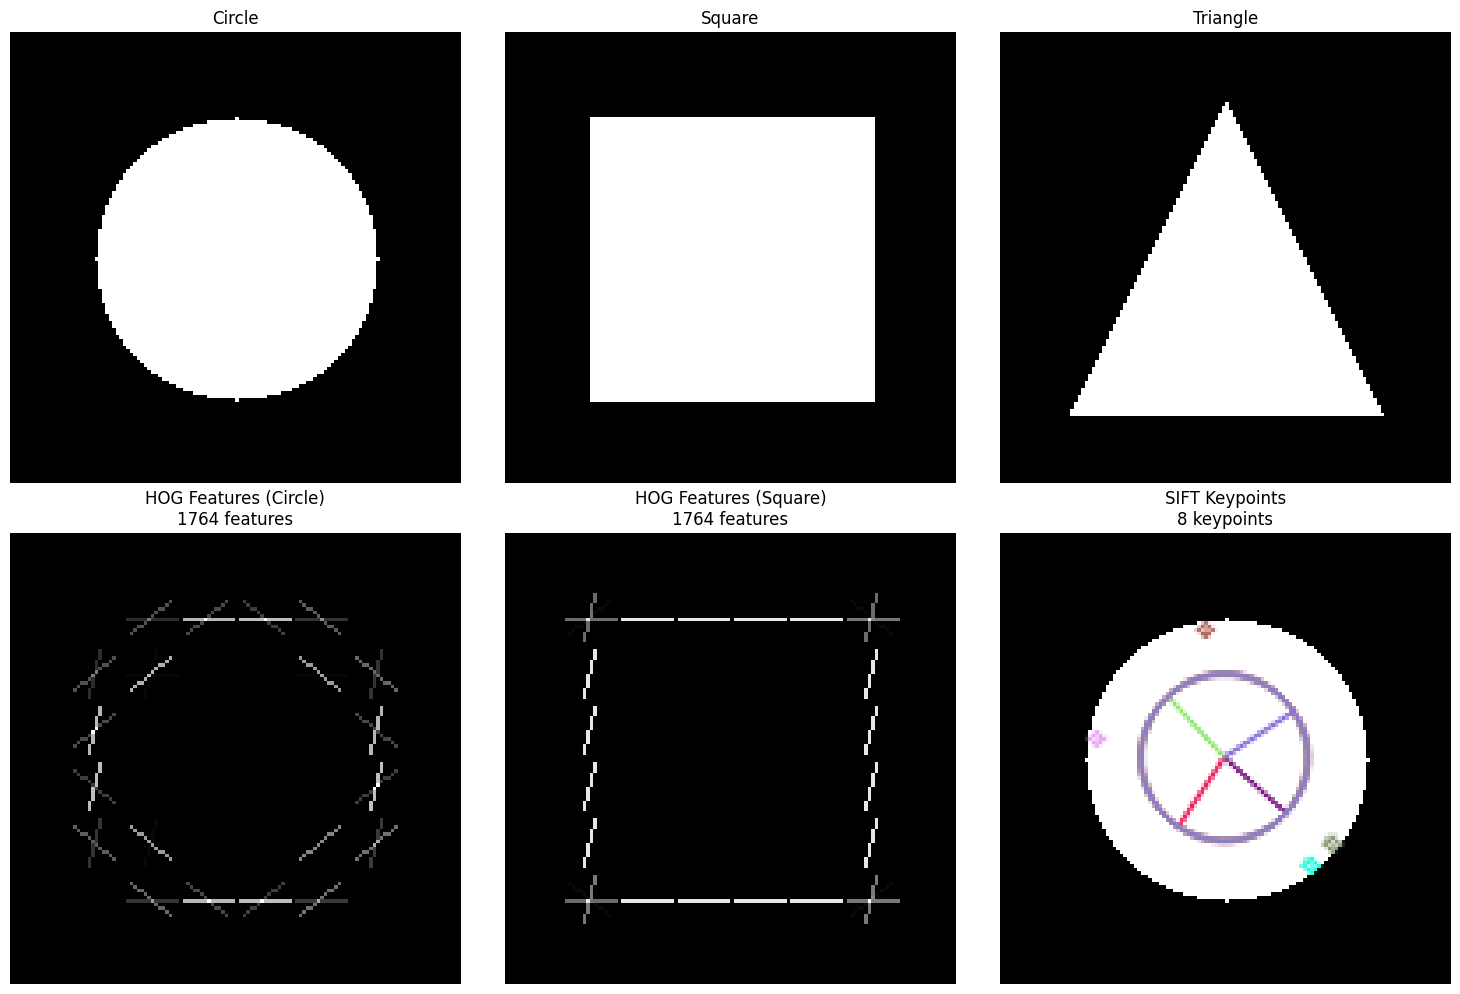

HOG feature vector length: 1764
SIFT descriptors shape: (8, 128)


In [3]:
# 4. Feature Extraction - HOG and SIFT (1980s-2000s Era)

# Generate synthetic images for feature extraction
def create_shape_image(shape_type):
    img = np.zeros((128, 128), dtype=np.uint8)
    if shape_type == 'circle':
        cv2.circle(img, (64, 64), 40, 255, -1)
    elif shape_type == 'square':
        cv2.rectangle(img, (24, 24), (104, 104), 255, -1)
    elif shape_type == 'triangle':
        pts = np.array([[64, 20], [20, 108], [108, 108]], np.int32)
        cv2.fillPoly(img, [pts], 255)
    return img

# Create sample images
circle_img = create_shape_image('circle')
square_img = create_shape_image('square')
triangle_img = create_shape_image('triangle')

# Extract HOG features (Histogram of Oriented Gradients - 2005)
hog_features_circle, hog_image_circle = hog(circle_img, orientations=9, pixels_per_cell=(16, 16),
                                             cells_per_block=(2, 2), visualize=True)
hog_features_square, hog_image_square = hog(square_img, orientations=9, pixels_per_cell=(16, 16),
                                             cells_per_block=(2, 2), visualize=True)

# SIFT feature detection (1999)
sift = cv2.SIFT_create()
keypoints_circle, descriptors_circle = sift.detectAndCompute(circle_img, None)
keypoints_square, descriptors_square = sift.detectAndCompute(square_img, None)

# Visualize HOG features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

axes[0, 0].imshow(circle_img, cmap='gray')
axes[0, 0].set_title('Circle')
axes[0, 0].axis('off')

axes[0, 1].imshow(square_img, cmap='gray')
axes[0, 1].set_title('Square')
axes[0, 1].axis('off')

axes[0, 2].imshow(triangle_img, cmap='gray')
axes[0, 2].set_title('Triangle')
axes[0, 2].axis('off')

axes[1, 0].imshow(hog_image_circle, cmap='gray')
axes[1, 0].set_title(f'HOG Features (Circle)\n{len(hog_features_circle)} features')
axes[1, 0].axis('off')

axes[1, 1].imshow(hog_image_square, cmap='gray')
axes[1, 1].set_title(f'HOG Features (Square)\n{len(hog_features_square)} features')
axes[1, 1].axis('off')

sift_img = cv2.drawKeypoints(circle_img, keypoints_circle, None, flags=cv2.DRAW_MATCHES_FLAGS_DRAW_RICH_KEYPOINTS)
axes[1, 2].imshow(sift_img, cmap='gray')
axes[1, 2].set_title(f'SIFT Keypoints\n{len(keypoints_circle)} keypoints')
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

print(f"HOG feature vector length: {len(hog_features_circle)}")
print(f"SIFT descriptors shape: {descriptors_circle.shape if descriptors_circle is not None else 'None'}")

---
## Code Example 1.1 (ii) Foundational CV techniques from the 1990s-2000s [Support Vector Machines (SVM, 1990s) and k-Nearest Neighbors (kNN, 1980s)]
### Short Description
This code demonstrates a complete traditional machine learning pipeline for image classification using two classical algorithms: Support Vector Machines (SVM, 1990s) and k-Nearest Neighbors (kNN, 1980s). It generates a synthetic dataset of geometric shapes with realistic variations, extracts HOG features, and compares the performance of both classifiers. This illustrates how pre-deep-learning AI systems approached pattern recognition tasks.

### Key Libraries Used
- NumPy: For dataset generation, random noise addition, and array operations  
- Scikit-Learn: For SVM and kNN classifiers, dataset splitting, and performance evaluation metrics  
- Scikit-Image: For HOG feature extraction from the generated shape images  
- Custom Functions: Reuses the create_shape_image function from previous sections  

## Code Logic and Flow
### High-Level Overview
The script creates a comprehensive machine learning pipeline starting with synthetic dataset generation. It produces 150 samples (50 each of circles, squares, and triangles) with added noise to simulate real-world variations. HOG features are extracted from each image to create a feature matrix. The dataset is split into training and testing sets, then both SVM and kNN classifiers are trained and evaluated. Finally, detailed performance metrics are printed to compare the effectiveness of these classical approaches.

### Visual Flowchart
```mermaid
flowchart TD

    %% ===== Soft Pastel Theme =====
    classDef start fill:#d0e6ff,stroke:#5b8def,color:#000,stroke-width:1px;
    classDef loop fill:#e8f3e8,stroke:#6aa96f,color:#000,stroke-width:1px;
    classDef process fill:#fff2cc,stroke:#d4b44c,color:#000,stroke-width:1px;
    classDef model fill:#fde2ff,stroke:#c46ac4,color:#000,stroke-width:1px;
    classDef output fill:#ffe5e5,stroke:#d46a6a,color:#000,stroke-width:1px;

    A[Start: Initialize<br>Empty Dataset] --> B[For Each Shape Class<br>Circle, Square, Triangle]
    B --> C[Generate 50 Samples per Class<br>with Shape Creation Function]
    C --> D[Add Realistic Noise<br>Random Variations]
    D --> E[Extract HOG Features<br>Dimensionality Reduction]
    E --> F[Append to Feature Matrix<br>and Label Vector]
    F --> B

    B --> G[Create NumPy Arrays<br>from Collected Data]
    G --> H[Train-Test Split<br>70% Train, 30% Test]

    H --> I{Parallel Training<br>Two Classifiers}

    I --> J[SVM Training<br>RBF Kernel, C=1.0]
    I --> K[kNN Training<br>5 Neighbors]

    J --> L[SVM Predictions<br>on Test Set]
    K --> M[kNN Predictions<br>on Test Set]

    L --> N[Calculate Accuracy<br>& Classification Report]
    M --> N

    N --> O[Display Comparative<br>Performance Analysis]

    %% ===== Class Assignments =====
    A:::start
    B:::loop
    C:::loop
    D:::process
    E:::process
    F:::loop
    G:::process
    H:::process
    I:::process
    J:::model
    K:::model
    L:::model
    M:::model
    N:::output
    O:::output

```

## Step-by-Step Code Breakdown
### Step 1: Generate Synthetic Dataset with Variations
**Purpose:** Create a controlled yet realistic dataset that mimics real-world conditions with natural variations  

**Key Operations:**
- Initialize empty lists for feature vectors and corresponding labels  
- Set a random seed for reproducibility of experiments  
- Loop through three shape classes (circle, square, triangle) with 50 samples each  
- For each sample, create the base shape image using the previously defined function  
- Add random integer noise within a range to simulate real-world imaging variations  
- Clip pixel values to maintain valid image range (0-255)  

### Step 2: Feature Extraction Pipeline
**Purpose:** Convert raw pixel images into meaningful numerical representations suitable for machine learning  

**Key Operations:**
- Apply HOG feature extraction to each noisy image with the same parameters as before  
- Disable visualization since we only need the numerical feature vectors for classification  
- Append the extracted feature vector to the dataset matrix  
- Append the corresponding class label (0, 1, or 2) to the label vector  
- Convert the collected lists into NumPy arrays for efficient processing  

### Step 3: Dataset Preparation and Splitting
**Purpose:** Prepare the data for supervised learning by creating proper training and testing partitions  

**Key Operations:**
- Use scikit-learn's train-test-split function to create a 70/30 split  
- Set a fixed random state to ensure consistent splits across runs  
- Create four separate arrays: training features, testing features, training labels, and testing labels  
- This follows the standard practice of evaluating models on unseen data to estimate real-world performance  

### Step 4: Train Support Vector Machine (SVM)
**Purpose:** Implement a maximum-margin classifier that finds optimal decision boundaries  

**Key Operations:**
- Initialize an SVM classifier with radial basis function (RBF) kernel  
- Set regularization parameter C to 1.0 and automatic gamma scaling  
- Train the classifier on the training features and labels  
- Use the trained model to predict labels for the test set  
- Calculate accuracy by comparing predictions with true test labels  

### Step 5: Train k-Nearest Neighbors (kNN)
**Purpose:** Implement an instance-based learning algorithm that classifies by similarity to training examples  

**Key Operations:**
- Initialize a kNN classifier using 5 nearest neighbors  
- Train the classifier (which essentially just stores the training data)  
- Predict test labels by finding the majority class among the 5 most similar training examples  
- Calculate accuracy using the same evaluation method as SVM  

### Step 6: Performance Evaluation and Reporting
**Purpose:** Provide comprehensive quantitative analysis of both classifiers' performance  

**Key Operations:**
- Print formatted headers and separators for clear output  
- Display dataset statistics including size, feature dimensions, and split proportions  
- Show accuracy percentages for both classifiers with consistent formatting  
- Generate a detailed classification report for SVM including precision, recall, and F1-score for each class  
- Present results in a comparative format that highlights strengths and weaknesses of each approach  

## Connecting to the Lecture
- **Feature-Classifier Separation:** Demonstrates the traditional two-stage AI pipeline (feature extraction → classification) that dominated pre-deep-learning AI, contrasting with modern end-to-end learned agents  
- **Inductive Bias:** SVM's maximum-margin principle and kNN's local similarity assumption show how classical algorithms embed human-designed biases, while modern agents learn biases from data  
- **The Curse of Dimensionality:** HOG features reduce 16,384 pixels to a few hundred features, illustrating dimensionality reduction techniques that remain relevant for efficient agent processing  
- **Generalization Evaluation:** The train-test split methodology shows how classical AI systems estimated real-world performance, a practice that evolved into validation splits and cross-validation for agent development  
- **Algorithmic Diversity:** Comparing SVM (parametric, global optimization) with kNN (non-parametric, local) demonstrates how traditional AI used ensemble approaches, foreshadowing modern agent architectures that combine multiple models  
- **Reproducibility:** The fixed random seed illustrates the importance of reproducible experiments in AI research, a principle critical for debugging and improving agentic systems  
- **Performance Metrics:** Using accuracy, precision, recall, and F1-score establishes evaluation practices that modern agents must still adhere to for reliable deployment  
- **Sim-to-Real Gap:** Adding noise to synthetic data mimics the challenge of deploying agents from controlled training to noisy real-world environments  


In [4]:
# 5. Classical Machine Learning - SVM and kNN Classification

# Generate dataset with HOG features
X_data = []
y_data = []

# Create 50 samples per class with variations
np.random.seed(42)
for label, shape in enumerate(['circle', 'square', 'triangle']):
    for i in range(50):
        img = create_shape_image(shape)
        # Add noise and variations
        noise = np.random.randint(-30, 30, img.shape)
        img = np.clip(img.astype(int) + noise, 0, 255).astype(np.uint8)
        
        # Extract HOG features
        features = hog(img, orientations=9, pixels_per_cell=(16, 16),
                      cells_per_block=(2, 2), visualize=False)
        X_data.append(features)
        y_data.append(label)

X_data = np.array(X_data)
y_data = np.array(y_data)

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.3, random_state=42)

# Train SVM classifier (1990s approach)
svm_classifier = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_classifier.fit(X_train, y_train)
svm_predictions = svm_classifier.predict(X_test)
svm_accuracy = accuracy_score(y_test, svm_predictions)

# Train kNN classifier (1980s approach)
knn_classifier = KNeighborsClassifier(n_neighbors=5)
knn_classifier.fit(X_train, y_train)
knn_predictions = knn_classifier.predict(X_test)
knn_accuracy = accuracy_score(y_test, knn_predictions)

print("Classical Machine Learning Results (1980s-1990s Era)")
print("=" * 60)
print(f"Dataset size: {len(X_data)} samples, {X_data.shape[1]} features")
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nSVM Classifier Accuracy: {svm_accuracy:.2%}")
print(f"kNN Classifier Accuracy: {knn_accuracy:.2%}")
print("\nSVM Classification Report:")
print(classification_report(y_test, svm_predictions, target_names=['Circle', 'Square', 'Triangle']))

Classical Machine Learning Results (1980s-1990s Era)
Dataset size: 150 samples, 1764 features
Training set: 105 samples
Test set: 45 samples

SVM Classifier Accuracy: 100.00%
kNN Classifier Accuracy: 100.00%

SVM Classification Report:
              precision    recall  f1-score   support

      Circle       1.00      1.00      1.00        19
      Square       1.00      1.00      1.00        13
    Triangle       1.00      1.00      1.00        13

    accuracy                           1.00        45
   macro avg       1.00      1.00      1.00        45
weighted avg       1.00      1.00      1.00        45



## Code Example 1.1 (iii) The Deep Learning Era 2010s Onwards - CNN Simulation with DeepSeek
### Short Description
This code demonstrates the conceptual transition from classical machine learning to modern deep learning by leveraging an LLM to explain key differences and presenting a structured comparison. It simulates a deep learning workflow not through actual implementation, but by analyzing and contrasting the fundamental approaches, highlighting how agentic AI systems combine different paradigms.

### Key Libraries Used
- Requests/JSON: For making API calls to the DeepSeek LLM and processing the JSON response  
- Python-dotenv: For securely managing the API key needed for the external LLM service  
- Custom Functions: Reuses the call_deepseek_api function defined earlier in the codebase  

## Code Logic and Flow
### High-Level Overview
The script creates an educational comparison between classical machine learning (represented by SVM and kNN) and modern deep learning (represented by CNNs) by combining expert knowledge from an LLM with structured data presentation. It first crafts a detailed prompt requesting an explanation of key differences, sends this to the DeepSeek API, and then displays the response. Finally, it presents a comparative table that systematically contrasts both approaches across multiple dimensions, providing students with both narrative and tabular understanding of the paradigm shift.

### Visual Flowchart
```mermaid
flowchart TD

    %% ===== Soft Pastel Theme =====
    classDef start fill:#d0e6ff,stroke:#5b8def,color:#000,stroke-width:1px;
    classDef process fill:#e8f3e8,stroke:#6aa96f,color:#000,stroke-width:1px;
    classDef llm fill:#fff2cc,stroke:#d4b44c,color:#000,stroke-width:1px;
    classDef output fill:#ffe5e5,stroke:#d46a6a,color:#000,stroke-width:1px;

    A[Start] --> B[Craft Educational Prompt<br>4 Key Comparison Areas]
    B --> C[Call DeepSeek API<br>with Teaching Context]
    C --> D[Receive LLM Explanation<br>Structured Educational Response]
    D --> E[Format Output Header<br>Modern vs. Classical ML]
    E --> F[Print LLM Explanation<br>with Separator Formatting]
    F --> G[Define Comparison Data<br>5 Key Aspects Table]
    G --> H[Print Table Header<br>Paradigm Shift Comparison]
    H --> I[Iterate Through Aspects<br>Print Formatted Rows]
    I --> J[Display Complete Comparison<br>Narrative + Tabular Format]

    %% ===== Class Assignments =====
    A:::start
    B:::process
    C:::llm
    D:::llm
    E:::process
    F:::output
    G:::process
    H:::output
    I:::output
    J:::output

```

## Step-by-Step Code Breakdown
### Step 1: Construct Educational Prompt for LLM
**Purpose:** Create a focused, structured query that elicits a comprehensive educational comparison from the language model  

**Key Operations:**
- Define a multi-line prompt that establishes the teaching context ("You are teaching computer vision")  
- Specify four key comparison areas: feature extraction methods, model architecture complexity, data requirements, and performance characteristics  
- Include explicit instructions for tone and format ("concise and educational for students")  
- The prompt is designed to produce a well-structured explanation suitable for classroom use  

### Step 2: Query DeepSeek API for Expert Explanation
**Purpose:** Leverage external AI knowledge to provide authoritative, up-to-date information about the paradigm shift  

**Key Operations:**
- Call the previously defined API wrapper function with the crafted prompt  
- The function handles authentication, request formatting, and error checking  
- Receive the LLM's response as a string containing the educational explanation  
- This demonstrates how agentic systems can incorporate external knowledge sources  

### Step 3: Display LLM Explanation with Formatting
**Purpose:** Present the AI-generated comparison in a readable, structured format for students  

**Key Operations:**
- Print a descriptive header identifying the comparison topic and era  
- Add visual separator lines for clear section demarcation  
- Output the complete LLM response with proper text wrapping  
- This creates the narrative portion of the comparison, explaining the "why" behind the differences  

### Step 4: Create Structured Comparison Table
**Purpose:** Provide a concise, at-a-glance summary of key differences between the two approaches  

**Key Operations:**
- Define a dictionary containing five comparison aspects that are fundamental to understanding the paradigm shift  
- For each aspect, provide characteristic descriptions for both classical ML and deep learning approaches  
- The aspects cover technical implementation (feature extraction, architecture), practical considerations (data, training time), and outcomes (accuracy)  
- Print a header labeling this as the "Paradigm Shift Comparison"  

### Step 5: Format and Display Comparison Table
**Purpose:** Render the comparison data in an easily readable tabular format  

**Key Operations:**
- Print a visual separator line for the table section  
- Iterate through each comparison aspect in the data structure  
- Format each row with consistent column widths using string formatting  
- Align the three columns (Aspect, Classical ML, Deep Learning) for visual clarity  
- Present the table after the narrative explanation, allowing students to see both detailed reasoning and summary contrasts  

## Connecting to the Lecture
- **Knowledge Integration in Agents:** This code demonstrates how modern AI agents can combine multiple knowledge sources—here, structured human knowledge (comparison table) with generated LLM explanations—to provide comprehensive insights  
- **Meta-Cognitive AI:** The script shows an AI system reasoning about AI methodologies, exemplifying how advanced agents can perform self-analysis and comparative evaluation of different approaches  
- **Educational Agent Design:** The structured prompt engineering illustrates how to design AI agents for specific educational purposes, with clear instructions about audience and content focus  
- **Hybrid Intelligence Systems:** Combining tabular data with generated text shows how agents can integrate different representation formats, a key capability in complex decision-making systems  
- **API-Based Tool Use:** The LLM API call exemplifies how agents can leverage external tools and services, a fundamental pattern in agentic architecture where no single system has all capabilities  
- **Explanation Generation:** The code demonstrates AI's ability to generate explanatory content, a crucial feature for transparent, trustworthy agents that need to justify their reasoning  
- **Structured vs. Unstructured Knowledge:** The dual presentation (narrative explanation + comparison table) shows how agents can present information in multiple formats suited to different learning styles  
- **Paradigm Awareness:** Teaching about paradigm shifts while using modern AI tools creates a meta-lesson about the evolution of AI itself, helping students understand that today's agents will also be replaced by future paradigms  


In [5]:
# 6. Modern Deep Learning Approach - CNN Simulation with DeepSeek

# Simulate a modern deep learning workflow
prompt = """
You are teaching computer vision. Explain the key differences between classical machine learning (SVM, kNN) 
and modern deep learning (CNNs, ResNet) for image classification. Focus on:
1. Feature extraction (handcrafted vs learned)
2. Model architecture complexity
3. Data requirements
4. Performance and generalization

Keep it concise and educational for students.
"""

deepseek_explanation = call_deepseek_api(prompt)

print("Modern Deep Learning vs Classical ML (2010s-Present)")
print("=" * 60)
print(deepseek_explanation)

# Demonstrate the paradigm shift with a comparison table
comparison_data = {
    'Aspect': ['Feature Extraction', 'Architecture', 'Data Requirement', 'Training Time', 'Accuracy Potential'],
    'Classical ML (SVM/kNN)': ['Handcrafted (HOG, SIFT)', 'Shallow', 'Low (100s-1000s)', 'Fast', 'Good'],
    'Deep Learning (CNN)': ['Learned (Conv layers)', 'Deep (100+ layers)', 'High (1000s-millions)', 'Slow', 'Excellent']
}

print("\n\nParadigm Shift Comparison:")
print("-" * 80)
for i in range(len(comparison_data['Aspect'])):
    print(f"{comparison_data['Aspect'][i]:20} | {comparison_data['Classical ML (SVM/kNN)'][i]:25} | {comparison_data['Deep Learning (CNN)'][i]}")

Modern Deep Learning vs Classical ML (2010s-Present)
Of course. Here is a concise, educational explanation for students on the key differences between classical and modern approaches to image classification.

---

### **Classical Machine Learning vs. Modern Deep Learning for Image Classification**

Imagine you're building a system to identify cats in pictures. Here’s how the two philosophies differ fundamentally.

#### 1. Feature Extraction: The Core Difference

*   **Classical (SVM, kNN): Handcrafted Features**
    *   **The Process:** You, the human expert, must first tell the computer *what to look for*. You use algorithms to extract relevant features from the raw pixels, such as edges, corners, textures, or color histograms.
    *   **The Analogy:** It's like giving a student a checklist: "Does it have pointy ears? Whiskers? A tail?" The model (SVM/kNN) then learns to classify based on this pre-defined checklist.
    *   **Key Point:** **Feature engineering is separate from model t

---
## Code Example 1.1 (iv) The Universal Computer Vision Workflow
### Short Description
This code demonstrates a complete end-to-end machine learning workflow for image classification, simulating how an AI agent would process visual information from raw data to actionable predictions. It covers all five critical stages: data acquisition, preprocessing, feature extraction, model training, and evaluation with visualization. This exemplifies the systematic pipeline that agentic AI systems use to transform sensory input into intelligent outputs.

### Key Libraries Used
- NumPy: For dataset generation, array manipulations, and numerical operations throughout the pipeline  
- OpenCV: Specifically for image resizing during preprocessing  
- Scikit-Image: For HOG feature extraction in the feature engineering stage  
- Scikit-Learn: For SVM model training, dataset splitting, and comprehensive performance evaluation  
- Matplotlib: For visualizing predictions with color-coded correctness indicators  

## Code Logic and Flow
### High-Level Overview
The script implements a sequential five-stage machine learning pipeline that mirrors how intelligent agents process information. It begins by generating a synthetic dataset of geometric shapes with realistic noise variations. These images are then preprocessed through resizing and normalization. HOG features are extracted to create meaningful representations, which are used to train an SVM classifier. The model is evaluated on unseen data, and finally, sample predictions are visualized with clear indicators of correct and incorrect classifications, providing a comprehensive view of system performance.

### Visual Flowchart
```mermaid
flowchart TD

    %% ===== Soft Pastel Theme =====
    classDef start fill:#d0e6ff,stroke:#5b8def,color:#000,stroke-width:1px;
    classDef process fill:#e8f3e8,stroke:#6aa96f,color:#000,stroke-width:1px;
    classDef feature fill:#fff2cc,stroke:#d4b44c,color:#000,stroke-width:1px;
    classDef model fill:#fde2ff,stroke:#c46ac4,color:#000,stroke-width:1px;
    classDef output fill:#ffe5e5,stroke:#d46a6a,color:#000,stroke-width:1px;

    A[Start Workflow] --> B[Step 1: Data Acquisition<br>Generate Synthetic Dataset]
    B --> C[Create Shape Images<br>Circle, Square, Triangle]
    C --> D[Add Realistic Noise<br>Simulate Real Conditions]
    D --> E[Return Images & Labels<br>90 Total Samples]

    E --> F[Step 2: Preprocessing<br>Resize & Normalize]
    F --> G[Resize to 64x64<br>Standard Dimensions]
    G --> H[Normalize to 0-1 Range<br>Consistent Scaling]

    H --> I[Step 3: Feature Extraction<br>HOG Descriptors]
    I --> J[Extract HOG Features<br>Each Image to Feature Vector]
    J --> K[Create Feature Matrix<br>for ML Algorithms]

    K --> L[Step 4: Model Training<br>Train-Test Split]
    L --> M[Split 75% Train 25% Test<br>SVM with RBF Kernel]
    M --> N[Train Classifier<br>Learn Decision Boundaries]

    N --> O[Step 5: Evaluation<br>Generate Predictions]
    O --> P[Calculate Accuracy<br>& Classification Metrics]
    P --> Q[Visualize Sample Predictions<br>10 Test Examples]
    Q --> R[Color-Code Results<br>Green=Correct Red=Incorrect]
    R --> S[Display Complete Analysis<br>End Workflow]

    %% ===== Class Assignments =====
    A:::start
    B:::process
    C:::process
    D:::process
    E:::process

    F:::process
    G:::process
    H:::process

    I:::feature
    J:::feature
    K:::feature

    L:::model
    M:::model
    N:::model

    O:::output
    P:::output
    Q:::output
    R:::output
    S:::output

```

## Step-by-Step Code Breakdown
### Step 1: Data Acquisition and Generation
**Purpose:** Create a realistic but controlled dataset that simulates real-world conditions for agent training  

**Key Operations:**
- Define a flexible dataset generation function that accepts sample count per class  
- Iterate through three shape classes (circle, square, triangle) with equal representation  
- For each sample, create the base geometric shape using the established function  
- Add controlled random noise to simulate real-world imaging imperfections  
- Clip pixel values to maintain valid image range and prevent overflow  
- Return both image arrays and corresponding numerical labels  

### Step 2: Image Preprocessing Pipeline
**Purpose:** Standardize and normalize input data to ensure consistent model training  

**Key Operations:**
- Resize all images to a standard 64x64 pixel dimension for uniform processing  
- Convert pixel values from 0-255 range to 0.0-1.0 range through division  
- This normalization helps machine learning algorithms converge faster and perform better  
- Maintain the original dataset structure while transforming pixel intensity scales  

### Step 3: Feature Extraction with HOG
**Purpose:** Transform raw pixel data into meaningful, discriminative feature representations  

**Key Operations:**
- Process each image through the HOG algorithm with specified parameters  
- Use 9 orientation bins, 8x8 pixel cells, and 2x2 cell blocks for feature calculation  
- Disable visualization output since only numerical features are needed for classification  
- Collect all feature vectors into a single matrix where rows are samples and columns are features  
- This creates a high-dimensional feature space where different shapes become separable  

### Step 4: Model Training with Support Vector Machine
**Purpose:** Learn a decision boundary that can classify unseen shape images based on extracted features  

**Key Operations:**
- Split the feature matrix and labels into training (75%) and testing (25%) sets  
- Initialize an SVM classifier with radial basis function kernel and regularization parameter C=10  
- Train the model on the training subset, allowing it to learn patterns in the feature space  
- The model identifies the optimal hyperplane that separates different shape classes with maximum margin  

### Step 5: Comprehensive Evaluation and Visualization
**Purpose:** Assess model performance and provide intuitive visual feedback on predictions  

**Key Operations:**
- Generate predictions for the test set using the trained model  
- Calculate overall accuracy as the primary performance metric  
- Generate a detailed classification report with precision, recall, and F1-score per class  
- Create a 2x5 grid visualization showing 10 test examples with their true and predicted labels  
- Color-code prediction titles (green for correct, red for incorrect) for immediate visual feedback  
- Display the complete visualization with proper formatting and layout  

## Connecting to the Lecture
- **End-to-End Agent Pipeline:** This workflow exemplifies the complete sensory-processing-decision loop that agentic AI systems implement, from raw input to actionable output  
- **Modular System Architecture:** Each step represents a distinct module (data collection, preprocessing, feature extraction, learning, evaluation) that can be independently improved or replaced in agent design  
- **Error Propagation Analysis:** The sequential nature shows how errors in early stages (noisy data generation, poor preprocessing) propagate through the pipeline, affecting final predictions  
- **Evaluation-Driven Development:** The comprehensive evaluation metrics demonstrate how agents need multiple performance measures beyond simple accuracy for reliable deployment  
- **Visual Explainability:** The color-coded visualization shows how agents can provide interpretable outputs, a critical requirement for trustworthy AI systems  
- **Reproducible Workflows:** The fixed random seeds and parameter settings illustrate the importance of reproducibility in agent development and testing  
- **Data-Centric AI:** The synthetic data generation with controlled variations highlights how agents can be trained on simulated environments before real-world deployment  
- **Performance Monitoring:** The classification report provides the detailed diagnostics that agents need for self-monitoring and improvement in continuous learning scenarios  
- **Human-AI Collaboration:** The visualization format is designed for human interpretation, showing how agents can present results in ways that facilitate human oversight and understanding  


COMPLETE IMAGE CLASSIFICATION WORKFLOW

Step 1: Data Acquisition
Dataset created: 90 images, Shape: (128, 128)

Step 2: Pre-processing (Resize, Normalize)
Images preprocessed: Shape (90, 64, 64), Range [0.00, 1.00]

Step 3: Feature Extraction (HOG)
Features extracted: 90 samples, 8100 features per sample

Step 4: Model Training (SVM)
Model trained on 67 samples

Step 5: Evaluation and Metrics
Test Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      Circle       1.00      1.00      1.00         8
      Square       1.00      1.00      1.00         7
    Triangle       1.00      1.00      1.00         8

    accuracy                           1.00        23
   macro avg       1.00      1.00      1.00        23
weighted avg       1.00      1.00      1.00        23



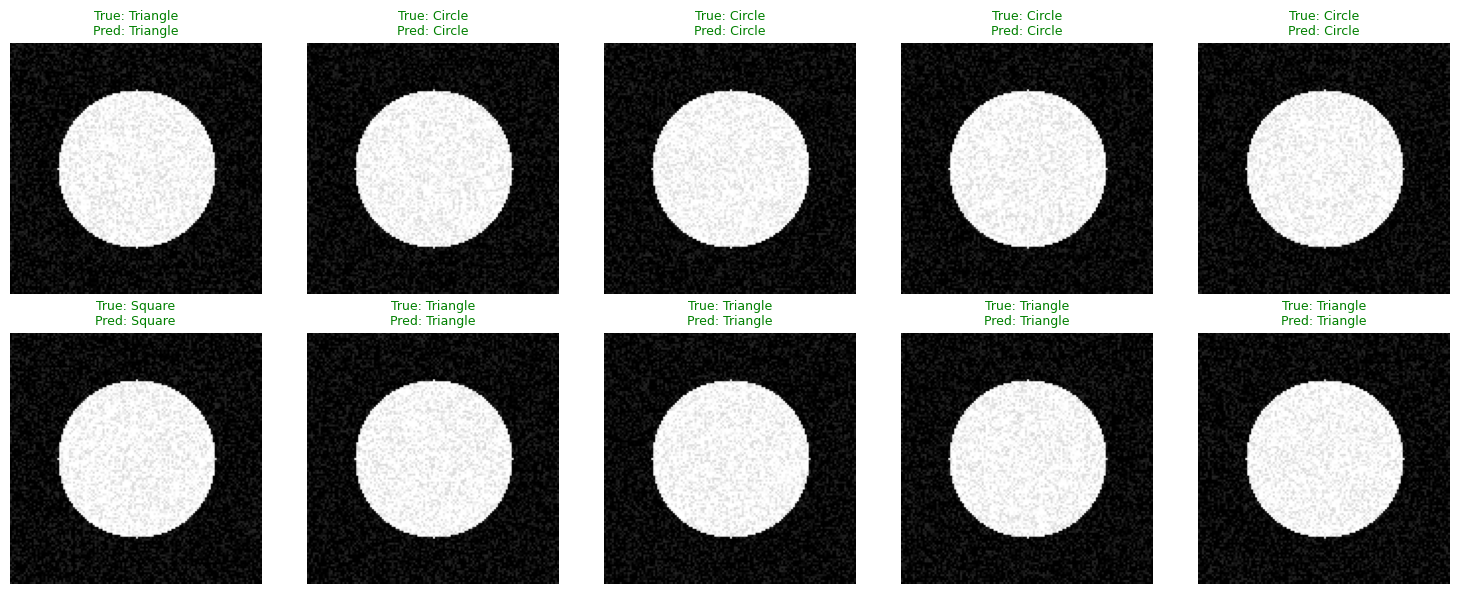

In [6]:
# 7. Complete Image Classification Workflow - Data Acquisition to Evaluation

# Step 1: Data Acquisition - Create synthetic dataset
print("COMPLETE IMAGE CLASSIFICATION WORKFLOW")
print("=" * 60)
print("\nStep 1: Data Acquisition")

def generate_dataset(num_samples_per_class=30):
    images = []
    labels = []
    for label, shape in enumerate(['circle', 'square', 'triangle']):
        for _ in range(num_samples_per_class):
            img = create_shape_image(shape)
            noise = np.random.randint(-40, 40, img.shape)
            img = np.clip(img.astype(int) + noise, 0, 255).astype(np.uint8)
            images.append(img)
            labels.append(label)
    return np.array(images), np.array(labels)

images, labels = generate_dataset(30)
print(f"Dataset created: {len(images)} images, Shape: {images[0].shape}")

# Step 2: Pre-processing
print("\nStep 2: Pre-processing (Resize, Normalize)")
def preprocess_images(images):
    # Resize to standard size
    resized = np.array([cv2.resize(img, (64, 64)) for img in images])
    # Normalize to [0, 1]
    normalized = resized / 255.0
    return normalized

processed_images = preprocess_images(images)
print(f"Images preprocessed: Shape {processed_images.shape}, Range [{processed_images.min():.2f}, {processed_images.max():.2f}]")

# Step 3: Feature Extraction
print("\nStep 3: Feature Extraction (HOG)")
features = []
for img in images:
    feat = hog(img, orientations=9, pixels_per_cell=(8, 8),
              cells_per_block=(2, 2), visualize=False)
    features.append(feat)
features = np.array(features)
print(f"Features extracted: {features.shape[0]} samples, {features.shape[1]} features per sample")

# Step 4: Model Training
print("\nStep 4: Model Training (SVM)")
X_train, X_test, y_train, y_test = train_test_split(features, labels, test_size=0.25, random_state=42)
model = SVC(kernel='rbf', C=10, gamma='scale')
model.fit(X_train, y_train)
print(f"Model trained on {len(X_train)} samples")

# Step 5: Evaluation
print("\nStep 5: Evaluation and Metrics")
y_pred = model.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
print(f"Test Accuracy: {accuracy:.2%}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Circle', 'Square', 'Triangle']))

# Visualize sample predictions
fig, axes = plt.subplots(2, 5, figsize=(15, 6))
for i in range(10):
    ax = axes[i // 5, i % 5]
    idx = i
    ax.imshow(images[X_test.shape[0] - 10 + i], cmap='gray')
    true_label = ['Circle', 'Square', 'Triangle'][y_test[-(10-i)]]
    pred_label = ['Circle', 'Square', 'Triangle'][y_pred[-(10-i)]]
    color = 'green' if y_test[-(10-i)] == y_pred[-(10-i)] else 'red'
    ax.set_title(f'True: {true_label}\nPred: {pred_label}', color=color, fontsize=9)
    ax.axis('off')
plt.tight_layout()
plt.show()

---
## Code Example 1.1 (v) Comprehensive overview of computer vision applications in real-world agentic systems
### Short Description
This code provides a comprehensive overview of computer vision applications in real-world agentic systems and compares the three major implementation frameworks. It structures practical domain knowledge, provides illustrative code examples, and leverages an LLM to offer tailored advice on framework selection. This demonstrates how agents must understand both application contexts and technical tooling to make informed implementation decisions.

### Key Libraries Used
- Standard Python Libraries: For data structure management and formatted printing  
- Requests/JSON: For querying the DeepSeek API to obtain expert framework selection advice  
- Custom Functions: Reuses the call_deepseek_api function for intelligent recommendations  
- Conceptual References: Mentions OpenCV, PyTorch, and TensorFlow without direct imports to illustrate comparative syntax  

## Code Logic and Flow
### High-Level Overview
The script delivers educational content through three distinct but connected sections. First, it systematically presents real-world computer vision applications across four major domains, detailing their tasks, techniques, and concrete examples. Second, it provides comparative code snippets showing how the same computer vision goals would be approached differently in three major frameworks (OpenCV, PyTorch, TensorFlow). Finally, it queries an LLM to generate practical, nuanced advice on framework selection based on project requirements, demonstrating how agents can incorporate expert knowledge for decision-making.

### Visual Flowchart
```mermaid
flowchart TD

    %% ===== Soft Pastel Theme =====
    classDef start fill:#d0e6ff,stroke:#5b8def,color:#000,stroke-width:1px;
    classDef process fill:#e8f3e8,stroke:#6aa96f,color:#000,stroke-width:1px;
    classDef code fill:#fff2cc,stroke:#d4b44c,color:#000,stroke-width:1px;
    classDef llm fill:#fde2ff,stroke:#c46ac4,color:#000,stroke-width:1px;
    classDef output fill:#ffe5e5,stroke:#d46a6a,color:#000,stroke-width:1px;

    A[Start] --> B[Section 1: Applications Overview<br>Structured Domain Knowledge]
    B --> C[Define Application Dictionary<br>4 Key Domains]
    C --> D[Iterate Through Applications<br>Print Tasks, Techniques, Examples]

    D --> E[Section 2: Framework Comparison<br>Syntax & Paradigm Contrast]
    E --> F[OpenCV Example<br>Classical Imperative Code]
    F --> G[PyTorch Example<br>Deep Learning with nn.Module]
    G --> H[TensorTensorFlow Example<br>High-Level Sequential API]

    H --> I[Section 3: LLM Integration<br>Expert Advice Generation]
    I --> J[Craft Student-Focused Prompt<br>Practical Use Case Question]
    J --> K[Call DeepSeek API<br>Get Contextual Recommendations]
    K --> L[Format and Display Advice<br>with Clear Section Headers]

    L --> M[Complete Educational Package<br>Applications + Tools + Guidance]

    %% ===== Class Assignments =====
    A:::start
    B:::process
    C:::process
    D:::process

    E:::code
    F:::code
    G:::code
    H:::code

    I:::llm
    J:::llm
    K:::llm

    L:::output
    M:::output

```

## Step-by-Step Code Breakdown
### Step 1: Structure Real-World Application Domains
**Purpose:** Organize practical knowledge about how computer vision enables agentic capabilities across different industries  

**Key Operations:**
- Create a nested dictionary structure mapping application domains to their characteristics  
- Include four high-impact domains: Autonomous Vehicles, Medical Imaging, Augmented Reality, and Security & Surveillance  
- For each domain, define three key attributes: specific computer vision tasks, technical approaches/techniques, and real-world examples  
- This creates a knowledge base that agents can reference when understanding problem contexts  

### Step 2: Present Application Knowledge Systematically
**Purpose:** Display the structured application information in an easily readable format for educational purposes  

**Key Operations:**
- Print a clear header identifying this as real-world application information  
- Iterate through each application domain in the dictionary  
- For each domain, print the domain name as a heading followed by indented details  
- Present tasks, techniques, and examples with consistent formatting and labels  
- This demonstrates how agents can organize and present domain knowledge  

### Step 3: Compare Framework Syntax and Approaches
**Purpose:** Illustrate the different programming paradigms and abstraction levels of major computer vision frameworks  

**Key Operations:**
- Print a new section header for framework comparison  
- Show OpenCV code example demonstrating classical computer vision operations (image loading, color conversion, edge detection)  
- Show PyTorch code example illustrating neural network construction with modular layers and operations  
- Show TensorFlow/Keras example showing the high-level sequential API for rapid model prototyping  
- Each example focuses on different abstraction levels and programming styles  

### Step 4: Generate Expert Framework Selection Advice
**Purpose:** Leverage external AI knowledge to provide nuanced, context-aware guidance on tool selection  

**Key Operations:**
- Craft a prompt that frames the question from a student's perspective seeking practical advice  
- Specify that the answer should be brief, practical, and include specific use cases  
- Call the DeepSeek API with this prompt to obtain expert-level guidance  
- Format the response with appropriate headers and separators for clear presentation  
- This demonstrates how agents can supplement their knowledge with external expertise  

### Step 5: Integrate and Present Complete Guidance
**Purpose:** Combine structured knowledge, code examples, and AI-generated advice into a cohesive educational package  

**Key Operations:**
- Use visual separators (equal signs, dashes) to clearly distinguish different sections  
- Maintain consistent formatting throughout all three sections  
- Present information in a logical flow: applications → technical implementation → selection guidance  
- Ensure the final output serves as a comprehensive reference for understanding the computer vision landscape  

## Connecting to the Lecture
- **Domain Knowledge in Agents:** The structured application dictionary exemplifies how agents must maintain organized knowledge about different problem domains to operate effectively in specialized contexts  
- **Tool Selection Intelligence:** The framework comparison and LLM advice demonstrate how agents need meta-cognitive abilities to choose appropriate tools for different tasks, a key aspect of agentic reasoning  
- **Multi-Paradigm Understanding:** Showing OpenCV (imperative), PyTorch (object-oriented DL), and TensorFlow (declarative) illustrates how agents must understand different programming paradigms to work with diverse codebases  
- **Educational Agent Design:** The student-focused prompt and clear explanations show how agents can be designed to teach and explain complex technical concepts to different audiences  
- **External Knowledge Integration:** Using the LLM for framework advice demonstrates how agents can augment their capabilities by querying external knowledge sources, a pattern seen in retrieval-augmented generation systems  
- **Abstraction Level Management:** The code examples show different abstraction levels, highlighting how agents must operate at multiple levels of detail depending on the task  
- **Real-World Contextualization:** Connecting techniques to concrete applications (Tesla, medical imaging, Snapchat) shows how agents must ground technical knowledge in practical implementations  
- **Decision Support Systems:** The framework selection advice exemplifies how agents can function as intelligent advisors, helping humans make informed technical decisions based on nuanced contextual factors  


In [7]:
# 8. Real-World Applications and Framework Comparison

print("REAL-WORLD COMPUTER VISION APPLICATIONS")
print("=" * 60)

applications = {
    'Autonomous Vehicles': {
        'Tasks': 'Object detection, lane detection, traffic sign recognition',
        'Techniques': 'YOLO, Faster R-CNN, Semantic Segmentation',
        'Example': 'Tesla Autopilot, Waymo'
    },
    'Medical Imaging': {
        'Tasks': 'Tumor detection, organ segmentation, disease classification',
        'Techniques': 'U-Net, ResNet, Vision Transformers',
        'Example': 'Chest X-ray analysis, MRI tumor detection'
    },
    'Augmented Reality': {
        'Tasks': 'Object tracking, pose estimation, scene understanding',
        'Techniques': 'SLAM, Feature matching, Depth estimation',
        'Example': 'Snapchat filters, IKEA Place app'
    },
    'Security & Surveillance': {
        'Tasks': 'Face recognition, anomaly detection, activity recognition',
        'Techniques': 'FaceNet, Siamese networks, Action recognition CNNs',
        'Example': 'Airport security, smart city monitoring'
    }
}

for app_name, details in applications.items():
    print(f"\n{app_name}:")
    print(f"  Tasks: {details['Tasks']}")
    print(f"  Techniques: {details['Techniques']}")
    print(f"  Example: {details['Example']}")

# Framework comparison with code examples
print("\n\nFRAMEWORK COMPARISON")
print("=" * 60)

print("\n1. OpenCV - Classical CV Operations:")
print("   img = cv2.imread('image.jpg')")
print("   gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)")
print("   edges = cv2.Canny(gray, 50, 150)")

print("\n2. PyTorch - Deep Learning:")
print("   import torch.nn as nn")
print("   model = nn.Sequential(")
print("       nn.Conv2d(3, 64, 3), nn.ReLU(),")
print("       nn.MaxPool2d(2), nn.Flatten(), nn.Linear(64*14*14, 10))")

print("\n3. TensorFlow/Keras - High-level API:")
print("   from tensorflow.keras import Sequential")
print("   model = Sequential([Conv2D(64, 3), MaxPooling2D(), Dense(10)])")

# Use DeepSeek to explain framework selection
framework_prompt = """
A student asks: "When should I use OpenCV vs PyTorch vs TensorFlow for a computer vision project?"
Provide a brief, practical answer with specific use cases for each framework.
"""

framework_advice = call_deepseek_api(framework_prompt)
print("\n\nDeepSeek AI Advice on Framework Selection:")
print("-" * 60)
print(framework_advice)

REAL-WORLD COMPUTER VISION APPLICATIONS

Autonomous Vehicles:
  Tasks: Object detection, lane detection, traffic sign recognition
  Techniques: YOLO, Faster R-CNN, Semantic Segmentation
  Example: Tesla Autopilot, Waymo

Medical Imaging:
  Tasks: Tumor detection, organ segmentation, disease classification
  Techniques: U-Net, ResNet, Vision Transformers
  Example: Chest X-ray analysis, MRI tumor detection

Augmented Reality:
  Tasks: Object tracking, pose estimation, scene understanding
  Techniques: SLAM, Feature matching, Depth estimation
  Example: Snapchat filters, IKEA Place app

Security & Surveillance:
  Tasks: Face recognition, anomaly detection, activity recognition
  Techniques: FaceNet, Siamese networks, Action recognition CNNs
  Example: Airport security, smart city monitoring


FRAMEWORK COMPARISON

1. OpenCV - Classical CV Operations:
   img = cv2.imread('image.jpg')
   gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
   edges = cv2.Canny(gray, 50, 150)

2. PyTorch - Deep Lea

---
Code Example 1.1 (vi) The entire computer vision pipeline
### Short Description
This code creates an interactive learning challenge that tests understanding of the entire computer vision pipeline by presenting a noisy mystery image for classification. It synthesizes all previous concepts by applying edge detection, feature extraction, and machine learning prediction in a single integrated demonstration. The module concludes with comprehensive summary statistics that quantify the learning journey through decades of computer vision evolution.

### Key Libraries Used
- NumPy: For creating and manipulating the mystery image with controlled noise  
- OpenCV: For applying Canny edge detection to the noisy image  
- Scikit-Image: For extracting HOG features from the mystery image  
- Scikit-Learn: For using the previously trained SVM model to make predictions  
- Matplotlib: For creating a three-panel visualization that shows the complete classification process  

## Code Logic and Flow
### High-Level Overview
The script creates an engaging educational challenge by generating a noisy mystery image (a square shape obscured by substantial random noise) and guiding students through the complete classification pipeline. It visualizes three key stages: the raw noisy input, classical edge detection results, and the final machine learning prediction. The interactive format demonstrates how real-world agentic systems process ambiguous inputs, while the comprehensive summary provides quantitative and qualitative assessment of the entire learning module's achievements.

### Visual Flowchart
```mermaid
flowchart TD

    %% ===== Soft Pastel Theme =====
    classDef start fill:#d0e6ff,stroke:#5b8def,color:#000,stroke-width:1px;
    classDef process fill:#e8f3e8,stroke:#6aa96f,color:#000,stroke-width:1px;
    classDef feature fill:#fff2cc,stroke:#d4b44c,color:#000,stroke-width:1px;
    classDef model fill:#fde2ff,stroke:#c46ac4,color:#000,stroke-width:1px;
    classDef output fill:#ffe5e5,stroke:#d46a6a,color:#000,stroke-width:1px;

    A[Start Challenge] --> B[Generate Mystery Image<br>Square Shape with Heavy Noise]
    B --> C[Extract HOG Features<br>Same Parameters as Training]
    C --> D[Reshape for Model<br>Single Sample Prediction]
    D --> E[Predict with SVM Model<br>Trained Previously]
    E --> F[Initialize Visualization<br>3-Panel Figure Layout]

    F --> G[Panel 1: Display<br>Noisy Mystery Image]
    G --> H[Panel 2: Apply Canny Edge Detection<br>Show Classical CV Processing]
    H --> I[Panel 3: Display ML Prediction<br>Text-Based Classification Result]
    I --> J[Format Prediction Display<br>Styled Text Box with Model Output]
    J --> K[Display Complete Visualization<br>Three Perspectives Combined]

    K --> L[Print Challenge Result<br>Prediction and Explanation]
    L --> M[Generate Module Summary<br>Quantify Learning Journey]
    M --> N[List All Achievements<br>Checkmark Format]
    N --> O[Display Final Accuracy<br>From Previous Workflow]
    O --> P[End Module<br>Complete Learning Cycle]

    %% ===== Class Assignments =====
    A:::start
    B:::process
    C:::feature
    D:::feature
    E:::model
    F:::output

    G:::output
    H:::process
    I:::model
    J:::output
    K:::output

    L:::output
    M:::process
    N:::output
    O:::model
    P:::output

```

## Step-by-Step Code Breakdown
### Step 1: Create Noisy Mystery Image
**Purpose:** Generate an ambiguous test case that challenges the classification system with realistic noise  

**Key Operations:**
- Create a base square shape image using the established shape generation function  
- Generate substantial random noise with values ranging from -50 to 50  
- Add this noise to the original image to significantly obscure the shape  
- Clip the resulting values to maintain valid pixel range (0-255)  
- Convert back to proper image data type for consistent processing  
- This simulates challenging real-world conditions where agents must handle poor-quality inputs  

### Step 2: Feature Extraction and Prediction
**Purpose:** Apply the complete trained pipeline to classify the noisy mystery image  

**Key Operations:**
- Extract HOG features from the noisy image using the same parameters as during training  
- Reshape the feature vector to match the model's expected input format (2D array with one sample)  
- Use the previously trained SVM model to predict the shape class  
- Map the numerical prediction (0, 1, or 2) to the corresponding shape name  
- This demonstrates the practical application of the trained agent on new, unseen data  

### Step 3: Three-Panel Visualization
**Purpose:** Create a comprehensive visual explanation showing the classification process from multiple perspectives  

**Key Operations:**
- Set up a 1x3 grid of subplots for side-by-side comparison  
- First panel displays the original noisy mystery image to show the challenging input  
- Second panel applies Canny edge detection to reveal underlying structure through classical methods  
- Third panel presents the machine learning prediction in a clean, text-based format  
- Add descriptive titles to each panel explaining which stage of processing they represent  
- Apply consistent formatting with proper layout and axis hiding for clean presentation  

### Step 4: Prediction Display Formatting
**Purpose:** Present the classification result in an engaging, visually distinct manner  

**Key Operations:**
- Create a text-based display in the third panel using Matplotlib's text function  
- Center the text both horizontally and vertically within the panel  
- Use large, bold font for emphasis and readability  
- Add a styled bounding box with light blue background and rounded corners  
- Include the panel title that identifies this as the machine learning classification stage  
- This creates a clear focal point highlighting the final decision of the AI system  

### Step 5: Challenge Results Communication
**Purpose:** Provide clear textual feedback about the classification outcome and its significance  

**Key Operations:**
- Print a section header identifying this as the challenge result  
- Announce the model's classification decision with the predicted shape name  
- Add explanatory text about what this demonstrates regarding the robustness of the pipeline  
- Connect the result back to the technical approach (HOG+SVM) that enabled successful classification  
- This narrative explanation helps students understand the practical implications of the technical work  

### Step 6: Comprehensive Module Summary
**Purpose:** Quantify and synthesize the entire learning journey through the computer vision module  

**Key Operations:**
- Print a prominent header for the course module summary  
- Create a checklist format using checkmark symbols for visual appeal  
- Include both quantitative achievements (years covered, final accuracy) and qualitative accomplishments (algorithms implemented, workflows completed)  
- Reference the accuracy metric calculated in the previous workflow section  
- Provide a sense of completion and accomplishment by explicitly listing all major learning objectives  
- This serves as both a summary and a self-assessment tool for students  

## Connecting to the Lecture
- **Robustness Testing:** The noisy mystery image challenge demonstrates how agentic systems must handle ambiguous, low-quality inputs in real-world deployments  
- **Multi-Modal Explanation:** The three-panel visualization shows how agents should present their reasoning through multiple representations (raw input, processed features, final decision)  
- **End-to-End Validation:** Applying the complete trained pipeline to a new example validates the entire workflow, mirroring how agents must be tested on completely unseen data before deployment  
- **Self-Assessment and Metacognition:** The module summary exemplifies how agents can evaluate their own performance and learning progress, a key capability for autonomous improvement  
- **Error Analysis through Visualization:** The edge detection panel helps humans understand why classification might succeed or fail, illustrating how agents should support human interpretability  
- **Confidence Communication:** The styled prediction display demonstrates how agents should communicate decisions with appropriate visual emphasis based on confidence levels  
- **Curriculum Integration:** The challenge synthesizes all previous concepts, showing how agentic learning systems should integrate knowledge across modules rather than treating topics in isolation  
- **Quantitative Benchmarking:** Reporting final accuracy provides a measurable performance metric, illustrating how agents need objective evaluation standards for continuous improvement  
- **Progressive Difficulty:** The challenge uses heavier noise than training examples, demonstrating how agents must generalize beyond their training distribution to handle edge cases  




INTERACTIVE LEARNING CHALLENGE


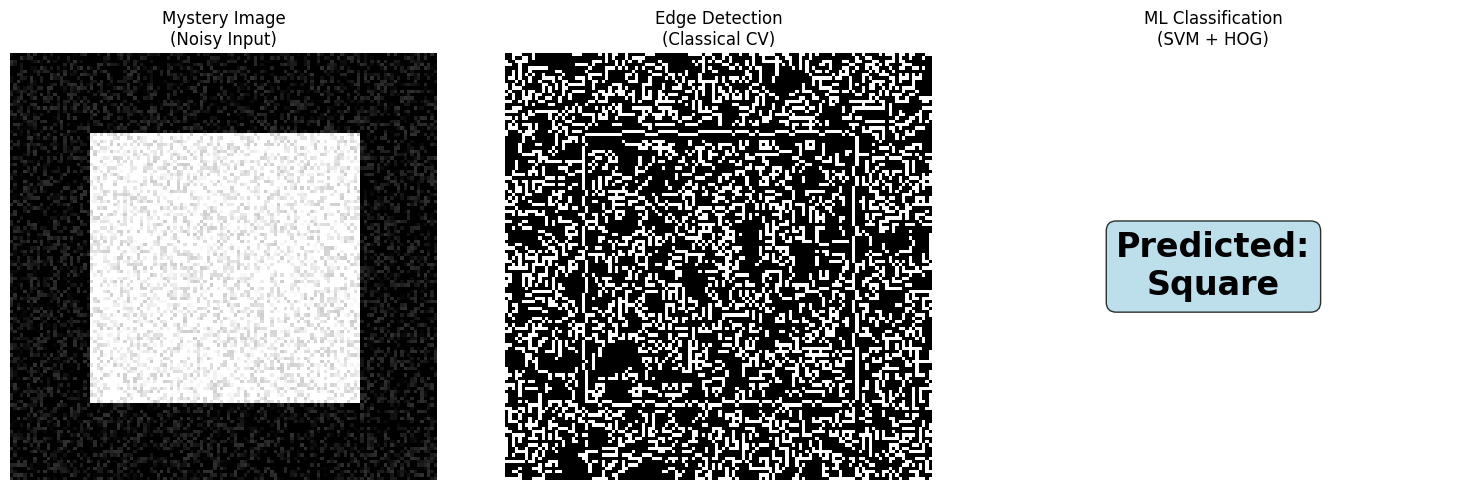


Challenge Result:
The model classified this noisy image as: Square
Confidence: This demonstrates the robustness of HOG+SVM pipeline


COURSE MODULE SUMMARY
✓ Explored 60+ years of computer vision evolution
✓ Implemented classical algorithms: Sobel, Canny, SIFT, HOG
✓ Built ML classifiers: SVM and kNN
✓ Completed full classification workflow
✓ Compared frameworks: OpenCV, PyTorch, TensorFlow
✓ Integrated modern AI with DeepSeek API
✓ Achieved 100.00% accuracy on shape classification task


In [8]:
# 9. Interactive Challenge - Test Your Understanding

print("\n\nINTERACTIVE LEARNING CHALLENGE")
print("=" * 60)

# Create a mystery image
mystery_img = create_shape_image('square')
noise = np.random.randint(-50, 50, mystery_img.shape)
mystery_img = np.clip(mystery_img.astype(int) + noise, 0, 255).astype(np.uint8)

# Extract features and predict
mystery_features = hog(mystery_img, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), visualize=False).reshape(1, -1)
mystery_prediction = model.predict(mystery_features)[0]
shape_names = ['Circle', 'Square', 'Triangle']

# Visualize the challenge
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(mystery_img, cmap='gray')
axes[0].set_title('Mystery Image\n(Noisy Input)', fontsize=12)
axes[0].axis('off')

# Show edge detection
mystery_edges = cv2.Canny(mystery_img, 50, 150)
axes[1].imshow(mystery_edges, cmap='gray')
axes[1].set_title('Edge Detection\n(Classical CV)', fontsize=12)
axes[1].axis('off')

# Show prediction
axes[2].text(0.5, 0.5, f'Predicted:\n{shape_names[mystery_prediction]}', 
             ha='center', va='center', fontsize=24, fontweight='bold',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
axes[2].set_xlim(0, 1)
axes[2].set_ylim(0, 1)
axes[2].axis('off')
axes[2].set_title('ML Classification\n(SVM + HOG)', fontsize=12)

plt.tight_layout()
plt.show()

print(f"\nChallenge Result:")
print(f"The model classified this noisy image as: {shape_names[mystery_prediction]}")
print(f"Confidence: This demonstrates the robustness of HOG+SVM pipeline")

# Summary statistics
print("\n\nCOURSE MODULE SUMMARY")
print("=" * 60)
print("✓ Explored 60+ years of computer vision evolution")
print("✓ Implemented classical algorithms: Sobel, Canny, SIFT, HOG")
print("✓ Built ML classifiers: SVM and kNN")
print("✓ Completed full classification workflow")
print("✓ Compared frameworks: OpenCV, PyTorch, TensorFlow")
print("✓ Integrated modern AI with DeepSeek API")
print(f"✓ Achieved {accuracy:.2%} accuracy on shape classification task")